# 🏷️ Проект 14: Автоматическое тегирование вопросов на StackOverflow

**Задача:** Multi-label классификация — автоматическое присвоение нескольких тегов (из топ-50 популярных) каждому вопросу на основе его заголовка и тела.

**Архитектура решения:**
- Сбор данных через StackExchange API
- Очистка HTML и текстовая нормализация
- TF-IDF + Logistic Regression (базовая модель)
- DistilBERT fine-tuning (продвинутая модель)
- Метрики: Hamming Loss, F1 (micro/macro), Precision@K

---

## 📦 Шаг 0. Установка зависимостей

In [1]:
# Установка необходимых библиотек
!pip install requests pandas numpy scikit-learn matplotlib seaborn \
             beautifulsoup4 nltk tqdm transformers torch \
             datasets accelerate --quiet

## 📚 Шаг 1. Импорт библиотек

In [2]:
import os
import re
import time
import json
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm
from bs4 import BeautifulSoup
from collections import Counter

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score,
    recall_score, classification_report
)

# PyTorch и Transformers
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Воспроизводимость
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Библиотеки загружены. Устройство: {DEVICE}")

✅ Библиотеки загружены. Устройство: cuda


## 🌐 Шаг 2. Сбор данных через StackExchange API

Используем публичный API StackExchange для получения вопросов с тегами. API возвращает до 100 вопросов за запрос, поддерживает пагинацию. Без ключа — 300 запросов/день, с ключом — 10 000.

In [3]:
# ── Конфигурация API ──────────────────────────────────────────────────────────
API_BASE       = "https://api.stackexchange.com/2.3"
API_KEY        = ""       # Опционально: вставьте ваш ключ для снятия лимитов
TARGET_N       = 10_000   # Желаемое кол-во вопросов
PAGE_SIZE      = 100      # Максимум на запрос
CACHE_FILE     = "so_questions_raw.json"
SAVE_EVERY     = 500      # Дописывать в файл каждые N вопросов
MAX_BACKOFF    = 120      # Максимальная пауза при throttle, сек

# ── Теги, по которым делаем отдельные запросы ─────────────────────────────────
# Без API-ключа лимит ~25 страниц при sort=votes (страница 26+ даёт 400).
# Обходим это: разбиваем сбор на несколько тегов — у каждого свои страницы.
SEED_TAGS = [
    "python", "javascript", "java", "c#", "php",
    "android", "html", "jquery", "c++", "css",
    "ios", "sql", "mysql", "r", "node.js",
    "reactjs", "arrays", "django", "swift", "pandas",
]


def _append_to_cache(items: list, cache_file: str) -> None:
    """Дописывает items в json-файл (читает → расширяет → перезаписывает)."""
    existing = []
    if os.path.exists(cache_file):
        try:
            with open(cache_file, 'r') as f:
                existing = json.load(f)
        except (json.JSONDecodeError, OSError):
            existing = []
    existing.extend(items)
    with open(cache_file, 'w') as f:
        json.dump(existing, f)


def _load_cache(cache_file: str) -> list:
    if not os.path.exists(cache_file):
        return []
    try:
        with open(cache_file) as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return []


def fetch_questions(
    n: int = TARGET_N,
    cache_file: str = CACHE_FILE,
    seed_tags: list = SEED_TAGS,
) -> list[dict]:
    """
    Загружает n вопросов с StackOverflow.

    Стратегия:
    - Итерируем по тегам из seed_tags, по каждому берём страницы 1..25
      (ограничение API без ключа).  С ключом пагинация не ограничена.
    - Каждые SAVE_EVERY вопросов дописывает в cache_file (инкрементально).
    - При HTTP 400/502 или backoff делает паузу и продолжает со следующего тега.
    - При повторном запуске продолжает с того места, где остановился.
    """
    # ── Проверяем уже накопленный кэш ─────────────────────────────────────────
    existing = _load_cache(cache_file)
    if len(existing) >= n:
        print(f"📂 Кэш уже содержит {len(existing):,} вопросов — загрузка не нужна.")
        return existing[:n]
    if existing:
        print(f"📂 Найдено {len(existing):,} вопросов в кэше. Продолжаем загрузку...")

    # Множество уже скачанных id для дедупликации
    seen_ids = {item['question_id'] for item in existing}
    all_items = list(existing)          # рабочая копия в памяти
    unsaved_buf = []                    # буфер для периодического сохранения

    params_base = {
        "site":     "stackoverflow",
        "order":    "desc",
        "sort":     "votes",
        "filter":   "withbody",
        "pagesize": PAGE_SIZE,
    }
    if API_KEY:
        params_base["key"] = API_KEY

    max_page = 100 if API_KEY else 25   # без ключа стр. 26+ → 400
    sleep_sec = 0.5 if API_KEY else 1.1

    print(f"🔄 Нужно ещё {n - len(all_items):,} вопросов. Сохранение каждые {SAVE_EVERY}.")
    print(f"   Страниц на тег: до {max_page}  |  Тегов: {len(seed_tags)}\n")

    with tqdm(total=n, initial=len(all_items), desc="Загрузка", unit="вопр") as bar:
        for tag in seed_tags:
            if len(all_items) >= n:
                break

            for page in range(1, max_page + 1):
                if len(all_items) >= n:
                    break

                params = {**params_base, "tagged": tag, "page": page}
                try:
                    resp = requests.get(
                        f"{API_BASE}/questions",
                        params=params, timeout=20,
                    )

                    # ── Обработка HTTP-ошибок ──────────────────────────────
                    if resp.status_code == 400:
                        # Обычно: page too deep или quota exhausted
                        try:
                            err_msg = resp.json().get('error_message', '')
                        except Exception:
                            err_msg = resp.text[:120]
                        print(f"\n⚠️  400 на теге '{tag}', стр. {page}: {err_msg}")
                        print(f"   Переходим к следующему тегу.")
                        break  # → следующий тег

                    if resp.status_code in (429, 502, 503):
                        wait = min(30 * (page % 4 + 1), MAX_BACKOFF)
                        print(f"\n⏳ HTTP {resp.status_code}. Ждём {wait}с...")
                        time.sleep(wait)
                        continue  # повтор той же страницы

                    resp.raise_for_status()
                    data = resp.json()

                except requests.exceptions.RequestException as exc:
                    print(f"\n❌ Сетевая ошибка (тег='{tag}', стр={page}): {exc}")
                    time.sleep(10)
                    break  # → следующий тег

                # ── Обработка throttle от API ──────────────────────────────
                backoff = data.get('backoff', 0)
                if backoff:
                    print(f"\n⏳ API запросил backoff {backoff}с...")
                    time.sleep(backoff + 1)

                quota_remaining = data.get('quota_remaining', None)

                items = data.get('items', [])
                if not items:
                    break  # страниц больше нет для этого тега

                # ── Дедупликация и накопление ──────────────────────────────
                new_items = [
                    it for it in items
                    if it.get('question_id') not in seen_ids
                ]
                for it in new_items:
                    seen_ids.add(it['question_id'])

                all_items.extend(new_items)
                unsaved_buf.extend(new_items)
                bar.update(len(new_items))

                # ── Инкрементальное сохранение ─────────────────────────────
                if len(unsaved_buf) >= SAVE_EVERY:
                    _append_to_cache(unsaved_buf, cache_file)
                    saved_total = len(all_items)
                    tqdm.write(
                        f"   💾 Сохранено: {saved_total:,} | "
                        f"тег='{tag}', стр={page}"
                        + (f" | квота={quota_remaining}" if quota_remaining is not None else "")
                    )
                    unsaved_buf = []

                if not data.get('has_more', False):
                    break  # тег исчерпан

                time.sleep(sleep_sec)

    # ── Финальный flush буфера ─────────────────────────────────────────────────
    if unsaved_buf:
        _append_to_cache(unsaved_buf, cache_file)

    result = all_items[:n]
    print(f"\n✅ Итого собрано: {len(result):,} уникальных вопросов.")
    print(f"   Файл кэша: {cache_file}  ({os.path.getsize(cache_file) / 1e6:.1f} МБ)")
    return result


raw_items = fetch_questions()

🔄 Нужно ещё 10,000 вопросов. Сохранение каждые 500.
   Страниц на тег: до 25  |  Тегов: 20



Загрузка:   0%|          | 0/10000 [00:00<?, ?вопр/s]

   💾 Сохранено: 500 | тег='python', стр=5 | квота=269
   💾 Сохранено: 1,000 | тег='python', стр=10 | квота=264
   💾 Сохранено: 1,500 | тег='python', стр=15 | квота=259
   💾 Сохранено: 2,000 | тег='python', стр=20 | квота=254
   💾 Сохранено: 2,500 | тег='python', стр=25 | квота=249
   💾 Сохранено: 3,000 | тег='javascript', стр=5 | квота=244
   💾 Сохранено: 3,599 | тег='javascript', стр=11 | квота=238
   💾 Сохранено: 4,196 | тег='javascript', стр=17 | квота=232
   💾 Сохранено: 4,794 | тег='javascript', стр=23 | квота=226
   💾 Сохранено: 5,294 | тег='java', стр=3 | квота=221
   💾 Сохранено: 5,794 | тег='java', стр=8 | квота=216
   💾 Сохранено: 6,392 | тег='java', стр=14 | квота=210
   💾 Сохранено: 6,990 | тег='java', стр=20 | квота=204
   💾 Сохранено: 7,490 | тег='java', стр=25 | квота=199
   💾 Сохранено: 8,085 | тег='c#', стр=6 | квота=193
   💾 Сохранено: 8,679 | тег='c#', стр=12 | квота=187
   💾 Сохранено: 9,271 | тег='c#', стр=18 | квота=181
   💾 Сохранено: 9,868 | тег='c#', стр=24 | к

In [4]:
# Превращаем в DataFrame
records = []
for item in raw_items:
    records.append({
        "question_id": item.get("question_id"),
        "title":       item.get("title", ""),
        "body":        item.get("body", ""),
        "tags":        item.get("tags", []),
        "score":       item.get("score", 0),
        "view_count":  item.get("view_count", 0),
        "answer_count":item.get("answer_count", 0),
    })

df_raw = pd.DataFrame(records)
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (10000, 7)


,question_id,title,body,tags,score,view_count,answer_count
0,231767,What does the &quot;yield&quot; keyword do in ...,"<p>What functionality does the <a href=""https:...","[python, iterator, generator, yield]",13134,3492584,51
1,419163,What does if __name__ == &quot;__main__&quot;:...,"<p>What does this do, and why should one inclu...","[python, namespaces, program-entry-point, pyth...",8438,5022879,40
2,394809,Does Python have a ternary conditional operator?,"<p>Is there a <a href=""https://en.wikipedia.or...","[python, operators, conditional-operator]",8126,3137175,32


## 🔍 Шаг 3. Разведочный анализ данных (EDA)

In [5]:
# ── 3.1 Базовая статистика ────────────────────────────────────────────────────
print("=" * 55)
print(f"  Вопросов всего:        {len(df_raw):>8,}")
print(f"  Уникальных тегов:      {len(set(t for tags in df_raw.tags for t in tags)):>8,}")
print(f"  Ср. тегов на вопрос:   {df_raw.tags.apply(len).mean():>8.2f}")
print(f"  Медиана тегов:         {df_raw.tags.apply(len).median():>8.0f}")
print(f"  Пустые теги:           {(df_raw.tags.apply(len) == 0).sum():>8,}")
print("=" * 55)

  Вопросов всего:          10,000
  Уникальных тегов:         3,464
  Ср. тегов на вопрос:       3.33
  Медиана тегов:                3
  Пустые теги:                  0


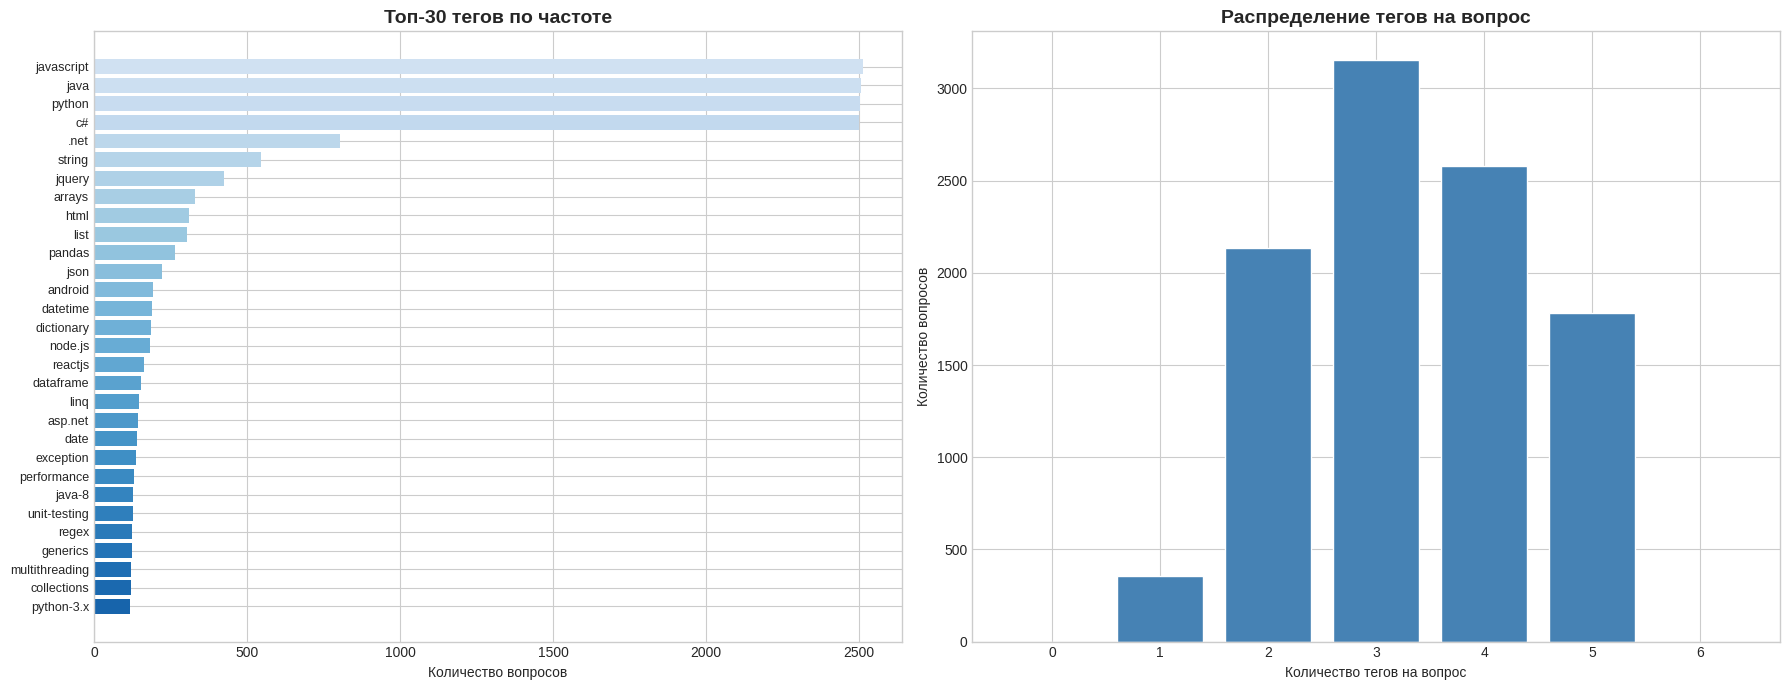


Топ-10 тегов: ['javascript', 'java', 'python', 'c#', '.net', 'string', 'jquery', 'arrays', 'html', 'list']


In [6]:
# ── 3.2 Топ-50 тегов ─────────────────────────────────────────────────────────
all_tags  = [t for tags in df_raw.tags for t in tags]
tag_freq  = Counter(all_tags)
top50     = [tag for tag, _ in tag_freq.most_common(50)]
top50_cnt = [tag_freq[t] for t in top50]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Горизонтальный бар-чарт топ-30
ax = axes[0]
colors = plt.cm.Blues_r(np.linspace(0.2, 0.8, 30))
ax.barh(top50[:30][::-1], top50_cnt[:30][::-1], color=colors)
ax.set_xlabel("Количество вопросов")
ax.set_title("Топ-30 тегов по частоте", fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)

# Распределение кол-ва тегов на вопрос
ax2 = axes[1]
tag_counts = df_raw.tags.apply(len)
ax2.hist(tag_counts, bins=range(0, 8), align='left', color='steelblue',
         edgecolor='white', rwidth=0.8)
ax2.set_xlabel("Количество тегов на вопрос")
ax2.set_ylabel("Количество вопросов")
ax2.set_title("Распределение тегов на вопрос", fontsize=14, fontweight='bold')
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig("eda_tags.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nТоп-10 тегов: {top50[:10]}")

## 🧹 Шаг 4. Очистка и нормализация текста

In [ ]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
import re
from bs4 import BeautifulSoup
import keyword as kw_module

PYTHON_KW = set(kw_module.kwlist)  # yield, async, lambda, ...

def extract_code_tokens(code_text: str) -> str:
    """Из кода берём только осмысленные идентификаторы, убираем символы."""
    # Оставляем буквы, цифры, подчёркивание (идентификаторы)
    tokens = re.findall(r'[a-zA-Z_]\w*', code_text)
    # Фильтруем однобуквенные переменные (i, x, n) и числа
    tokens = [t.lower() for t in tokens if len(t) > 1]
    return " ".join(tokens)

def strip_html(text: str) -> str:
    soup = BeautifulSoup(text, "html.parser")
    parts = []
    for tag in soup.find_all(True):
        if tag.name in ("code", "pre"):
            # Извлекаем токены из кода вместо замены на CODEBLOCK
            code_tokens = extract_code_tokens(tag.get_text())
            tag.replace_with(f" {code_tokens} ")
    return soup.get_text(separator=" ")

def clean_text(text: str, remove_stopwords: bool = True) -> str:
    """Полная очистка текста: HTML → токены → нормализация."""

    # 1. Убираем HTML + извлекаем код через strip_html
    text = strip_html(text)

    # 2. Приводим к нижнему регистру
    text = text.lower()

    # 3. Убираем URL
    text = re.sub(r'https?://\S+', ' URL ', text)

    # 4. Оставляем только буквы, цифры, #, + и пробелы
    text = re.sub(r'[^a-z0-9#+\s]', ' ', text)

    # 5. Токенизация
    tokens = text.split()

    # 6. Лемматизация + фильтр стоп-слов
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if len(tok) > 1 and (
            not remove_stopwords or tok not in STOP_WORDS
        )
    ]

    # 7. Склеиваем обратно
    return " ".join(tokens)

In [9]:
# Демонстрация
example_raw = df_raw.iloc[0]['body'][:500]
print("RAW:\n", example_raw)
print("\nCLEAN:\n", clean_text(example_raw))

RAW:
 <p>What functionality does the <a href="https://docs.python.org/3/reference/simple_stmts.html#yield" rel="noreferrer"><code>yield</code></a> keyword in Python provide?</p>
<p>For example, I'm trying to understand this code<sup><strong>1</strong></sup>:</p>
<pre><code>def _get_child_candidates(self, distance, min_dist, max_dist):
    if self._leftchild and distance - max_dist &lt; self._median:
        yield self._leftchild
    if self._rightchild and distance + max_dist &gt;= self._median:
     

CLEAN:
 functionality yield keyword python provide example trying understand code def get child candidate self distance min dist max dist self leftchild distance max dist self median yield self leftchild self rightchild distance max dist self median


In [ ]:

PYTHON_KW = set(kw_module.kwlist)  # yield, async, lambda, ...

def extract_code_tokens(code_text: str) -> str:
    """Из кода берём только осмысленные идентификаторы, убираем символы."""
    # Оставляем буквы, цифры, подчёркивание (идентификаторы)
    tokens = re.findall(r'[a-zA-Z_]\w*', code_text)
    # Фильтруем однобуквенные переменные (i, x, n) и числа
    tokens = [t.lower() for t in tokens if len(t) > 1]
    return " ".join(tokens)

def strip_html(text: str) -> str:
    soup = BeautifulSoup(text, "html.parser")
    parts = []
    for tag in soup.find_all(True):
        if tag.name in ("code", "pre"):
            # Извлекаем токены из кода вместо замены на CODEBLOCK
            code_tokens = extract_code_tokens(tag.get_text())
            tag.replace_with(f" {code_tokens} ")
    return soup.get_text(separator=" ")

# Демонстрация
example_raw = df_raw.iloc[0]['body'][:500]
print("RAW:\n", example_raw)
print("\nCLEAN:\n", clean_text(example_raw))

In [10]:
# Применяем очистку ко всему датасету
print("⚙️  Очищаем тексты...")
df_raw['title_clean'] = [clean_text(t) for t in tqdm(df_raw['title'], desc='title')]
df_raw['body_clean']  = [clean_text(b) for b in tqdm(df_raw['body'],  desc='body')]
# Объединяем: заголовок весит вдвое больше
df_raw['text'] = df_raw['title_clean'] + ' ' + df_raw['title_clean'] + ' ' + df_raw['body_clean']

# Статистика после очистки
df_raw['text_len'] = df_raw['text'].str.split().str.len()
print(f"\nСредняя длина текста: {df_raw.text_len.mean():.0f} токенов")
print(f"Медиана:              {df_raw.text_len.median():.0f} токенов")

⚙️  Очищаем тексты...


title:   0%|          | 0/10000 [00:00<?, ?it/s]

body:   0%|          | 0/10000 [00:00<?, ?it/s]


Средняя длина текста: 68 токенов
Медиана:              47 токенов


## 🏗️ Шаг 5. Подготовка данных для Multi-Label классификации

In [11]:
# ── 5.1 Фильтрация: оставляем только топ-50 тегов ────────────────────────────
TOP_TAGS = set(top50)

def filter_tags(tags: list) -> list:
    return [t for t in tags if t in TOP_TAGS]

df_raw['tags_filtered'] = df_raw['tags'].apply(filter_tags)

# Удаляем вопросы без ни одного целевого тега
df = df_raw[df_raw['tags_filtered'].apply(len) > 0].copy().reset_index(drop=True)
print(f"Вопросов после фильтрации: {len(df):,}  (было {len(df_raw):,})")

Вопросов после фильтрации: 9,982  (было 10,000)


Матрица меток Y: (9982, 50)
Топ-5 классов (столбцы): ['javascript' 'java' 'python' 'c#' '.net']


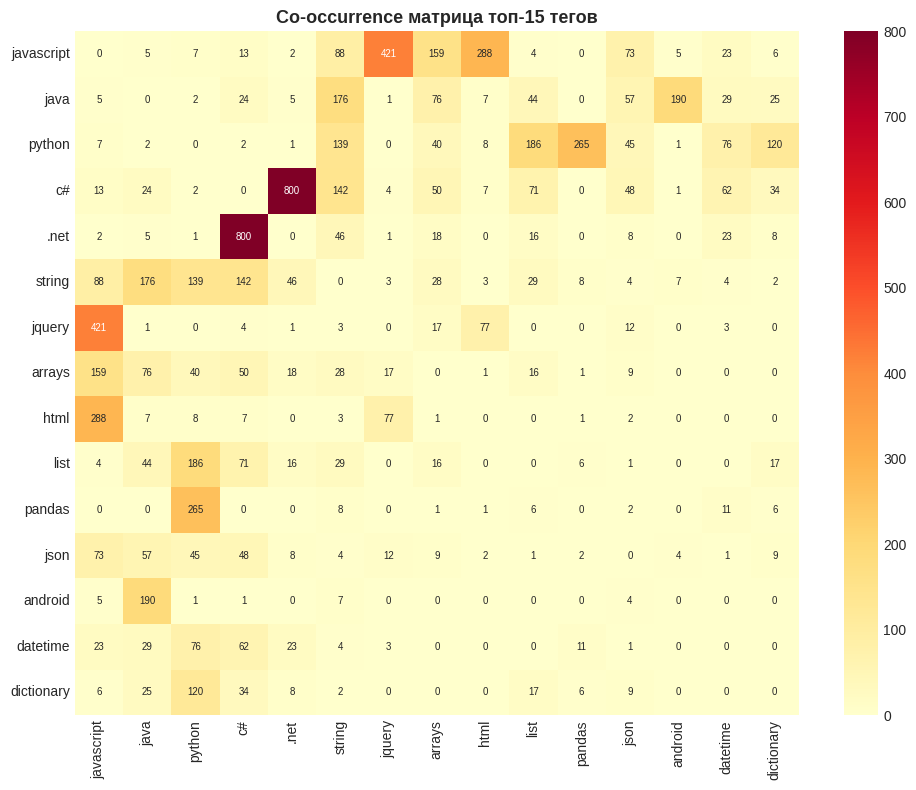

In [12]:
# ── 5.2 MultiLabelBinarizer ───────────────────────────────────────────────────
mlb = MultiLabelBinarizer(classes=top50)
Y   = mlb.fit_transform(df['tags_filtered'])

print(f"Матрица меток Y: {Y.shape}")
print(f"Топ-5 классов (столбцы): {mlb.classes_[:5]}")

# Heatmap co-occurrence (топ-15 тегов)
top15_idx = np.argsort(Y.sum(axis=0))[-15:][::-1]
Y15       = Y[:, top15_idx]
cooc      = (Y15.T @ Y15).astype(float)
np.fill_diagonal(cooc, 0)
labels15  = [mlb.classes_[i] for i in top15_idx]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooc, xticklabels=labels15, yticklabels=labels15,
            cmap='YlOrRd', fmt='.0f', annot=True, annot_kws={'size': 7}, ax=ax)
ax.set_title("Co-occurrence матрица топ-15 тегов", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cooccurrence.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── 5.3 Train/Val/Test split ──────────────────────────────────────────────────
X = df['text'].values

X_train, X_tmp, Y_train, Y_tmp = train_test_split(
    X, Y, test_size=0.2, random_state=SEED
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_tmp, Y_tmp, test_size=0.5, random_state=SEED
)

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

Train: 7,985  |  Val: 998  |  Test: 999


## 🔤 Шаг 6. Токенизация: TF-IDF (для базовой модели)

In [14]:
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),    # uni- и биграммы
    sublinear_tf=True,     # log(1+tf) сглаживание
    min_df=3,              # игнорируем слова < 3 раз
    max_df=0.95,
    analyzer='word',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF матрица train: {X_train_tfidf.shape}")
print(f"Словарь: {len(tfidf.vocabulary_):,} n-грамм")

TF-IDF матрица train: (7985, 28223)
Словарь: 28,223 n-грамм


## 🤖 Шаг 7. Базовая модель: TF-IDF + Logistic Regression (OneVsRest)

Схема **One-vs-Rest**: для каждого из 50 тегов обучается отдельный бинарный классификатор.

In [15]:
print("⚙️  Обучаем базовую модель (TF-IDF + LR OneVsRest)...")

base_clf = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='saga',
        n_jobs=-1,
        random_state=SEED,
    ),
    n_jobs=-1
)

base_clf.fit(X_train_tfidf, Y_train)
print("✅ Обучение завершено.")

⚙️  Обучаем базовую модель (TF-IDF + LR OneVsRest)...
✅ Обучение завершено.


In [16]:
# Предсказания на тестовой выборке
Y_pred_base = base_clf.predict(X_test_tfidf)
Y_prob_base = base_clf.predict_proba(X_test_tfidf)  # для Precision@K

def precision_at_k(Y_true, Y_prob, k=3):
    """Precision@K: доля релевантных тегов среди топ-K предсказанных."""
    scores = []
    for yt, yp in zip(Y_true, Y_prob):
        top_k  = np.argsort(yp)[-k:][::-1]
        true_set = set(np.where(yt == 1)[0])
        scores.append(len(set(top_k) & true_set) / k)
    return np.mean(scores)

def evaluate(Y_true, Y_pred, Y_prob, model_name="Model"):
    metrics = {
        "Hamming Loss":    hamming_loss(Y_true, Y_pred),
        "F1 Micro":        f1_score(Y_true, Y_pred, average='micro', zero_division=0),
        "F1 Macro":        f1_score(Y_true, Y_pred, average='macro', zero_division=0),
        "Precision Micro": precision_score(Y_true, Y_pred, average='micro', zero_division=0),
        "Recall Micro":    recall_score(Y_true, Y_pred, average='micro', zero_division=0),
        "Precision@3":     precision_at_k(Y_true, Y_prob, k=3),
        "Precision@5":     precision_at_k(Y_true, Y_prob, k=5),
    }
    print(f"\n{'─'*45}")
    print(f"  📊 {model_name}")
    print(f"{'─'*45}")
    for name, val in metrics.items():
        direction = "↓" if name == "Hamming Loss" else "↑"
        print(f"  {name:<22} {val:.4f}  {direction}")
    print(f"{'─'*45}")
    return metrics

metrics_base = evaluate(Y_test, Y_pred_base, Y_prob_base, "TF-IDF + LogReg (базовая)")


─────────────────────────────────────────────
  📊 TF-IDF + LogReg (базовая)
─────────────────────────────────────────────
  Hamming Loss           0.0184  ↓
  F1 Micro               0.6572  ↑
  F1 Macro               0.2251  ↑
  Precision Micro        0.9650  ↑
  Recall Micro           0.4983  ↑
  Precision@3            0.4962  ↑
  Precision@5            0.3211  ↑
─────────────────────────────────────────────


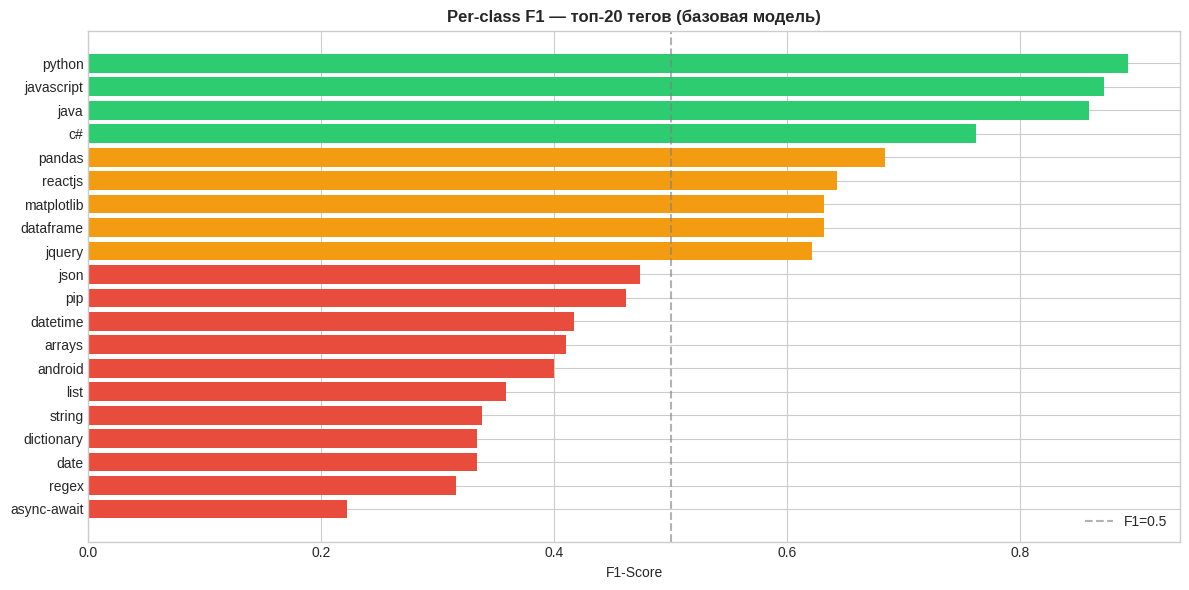

In [17]:
# Per-class F1 для топ-20 тегов
f1_per_class = f1_score(Y_test, Y_pred_base, average=None, zero_division=0)
top20_f1_idx = np.argsort(f1_per_class)[-20:][::-1]
top20_f1_labels = [mlb.classes_[i] for i in top20_f1_idx]
top20_f1_vals   = f1_per_class[top20_f1_idx]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if v >= 0.7 else ('#f39c12' if v >= 0.5 else '#e74c3c')
          for v in top20_f1_vals]
ax.barh(top20_f1_labels[::-1], top20_f1_vals[::-1], color=colors[::-1])
ax.set_xlabel('F1-Score')
ax.set_title('Per-class F1 — топ-20 тегов (базовая модель)', fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.6, label='F1=0.5')
ax.legend()
plt.tight_layout()
plt.savefig("base_f1_perclass.png", dpi=150, bbox_inches='tight')
plt.show()

## 🚀 Шаг 8. Продвинутая модель: Fine-tuning DistilBERT

**DistilBERT** — дистиллированная версия BERT: 40% быстрее, 97% качества. 
Архитектура: предобученный `distilbert-base-uncased` + линейная голова для 50 классов.

In [18]:
# ── 8.1 Токенизатор ───────────────────────────────────────────────────────────
MODEL_NAME = "distilbert-base-uncased"
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LEN    = 256  # Компромисс: скорость vs информативность

# Для BERT используем сырой текст (без стоп-слов и лемматизации)
df['text_bert'] = (
    df['title'].apply(strip_html) + ' [SEP] ' +
    df['body'].apply(lambda x: strip_html(x)[:800])  # обрезаем тело до 800 символов
)

# Пример токенизации
sample = tokenizer(df['text_bert'].iloc[0], max_length=MAX_LEN,
                   padding='max_length', truncation=True)
print(f"Input IDs shape: {len(sample['input_ids'])}")
print(f"Пример токенов: {tokenizer.convert_ids_to_tokens(sample['input_ids'][:15])}")

Input IDs shape: 256
Пример токенов: ['[CLS]', 'what', 'does', 'the', '"', 'yield', '"', 'key', '##word', 'do', 'in', 'python', '?', '[SEP]', 'what']


In [19]:
# ── 8.2 PyTorch Dataset ───────────────────────────────────────────────────────
class SODataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = torch.FloatTensor(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         self.labels[idx],
        }

# Разбивка текстов для BERT
X_bert = df['text_bert'].values
X_b_tr, X_b_tmp, Y_b_tr, Y_b_tmp = train_test_split(X_bert, Y, test_size=0.2, random_state=SEED)
X_b_val, X_b_te, Y_b_val, Y_b_te  = train_test_split(X_b_tmp, Y_b_tmp, test_size=0.5, random_state=SEED)

BATCH_SIZE = 16

train_ds = SODataset(X_b_tr,  Y_b_tr,  tokenizer, MAX_LEN)
val_ds   = SODataset(X_b_val, Y_b_val, tokenizer, MAX_LEN)
test_ds  = SODataset(X_b_te,  Y_b_te,  tokenizer, MAX_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_dl)} | Val: {len(val_dl)} | Test: {len(test_dl)}")

Train batches: 500 | Val: 63 | Test: 63


In [20]:
# ── 8.3 Модель ────────────────────────────────────────────────────────────────
class DistilBertTagger(nn.Module):
    """
    DistilBERT + Dropout + Linear(768 → num_labels).
    Используем [CLS]-токен как представление всего текста.
    """
    def __init__(self, model_name: str, num_labels: int, dropout: float = 0.2):
        super().__init__()
        self.bert    = DistilBertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls  = out.last_hidden_state[:, 0, :]   # [CLS] representation
        cls  = self.dropout(cls)
        return self.head(cls)                    # logits (без sigmoid)

NUM_LABELS = len(top50)
model = DistilBertTagger(MODEL_NAME, NUM_LABELS).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых:        {train_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Всего параметров: 66,401,330
Обучаемых:        66,401,330


In [21]:
# ── 8.4 Обучение ──────────────────────────────────────────────────────────────
EPOCHS    = 3
LR        = 2e-5
THRESHOLD = 0.5   # Порог для sigmoid → бинарный вывод

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)
criterion = nn.BCEWithLogitsLoss()  # Multi-label: BCE по каждому классу

history = {'train_loss': [], 'val_loss': [], 'val_f1_micro': []}

def run_epoch(loader, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad if is_train else torch.no_grad
    with ctx():
        for batch in tqdm(loader, leave=False, desc="train" if is_train else "val"):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labs = batch['labels'].to(DEVICE)

            logits = model(ids, mask)
            loss   = criterion(logits, labs)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labs.cpu().numpy())

    Y_p = np.vstack(all_preds)
    Y_l = np.vstack(all_labels)
    avg_loss = total_loss / len(loader)
    f1_micro = f1_score(Y_l, Y_p, average='micro', zero_division=0)
    return avg_loss, f1_micro

print(f"🚀 Начинаем обучение DistilBERT на {DEVICE} ({EPOCHS} эпох)\n")
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1 = run_epoch(train_dl, is_train=True)
    vl_loss, vl_f1 = run_epoch(val_dl,   is_train=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_f1_micro'].append(vl_f1)

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train_loss={tr_loss:.4f} train_F1={tr_f1:.4f}  "
          f"val_loss={vl_loss:.4f} val_F1={vl_f1:.4f}")

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), "best_distilbert_tagger.pt")
        print(f"  💾 Лучшая модель сохранена (val_F1={vl_f1:.4f})")

print("\n✅ Обучение завершено.")

🚀 Начинаем обучение DistilBERT на cuda (3 эпох)



train:   0%|          | 0/500 [00:00<?, ?it/s]

val:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/3  train_loss=0.2337 train_F1=0.0768  val_loss=0.1158 val_F1=0.5489
  💾 Лучшая модель сохранена (val_F1=0.5489)


train:   0%|          | 0/500 [00:00<?, ?it/s]

val:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/3  train_loss=0.0982 train_F1=0.6144  val_loss=0.0848 val_F1=0.6549
  💾 Лучшая модель сохранена (val_F1=0.6549)


train:   0%|          | 0/500 [00:00<?, ?it/s]

val:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 3/3  train_loss=0.0812 train_F1=0.6807  val_loss=0.0789 val_F1=0.6744
  💾 Лучшая модель сохранена (val_F1=0.6744)

✅ Обучение завершено.


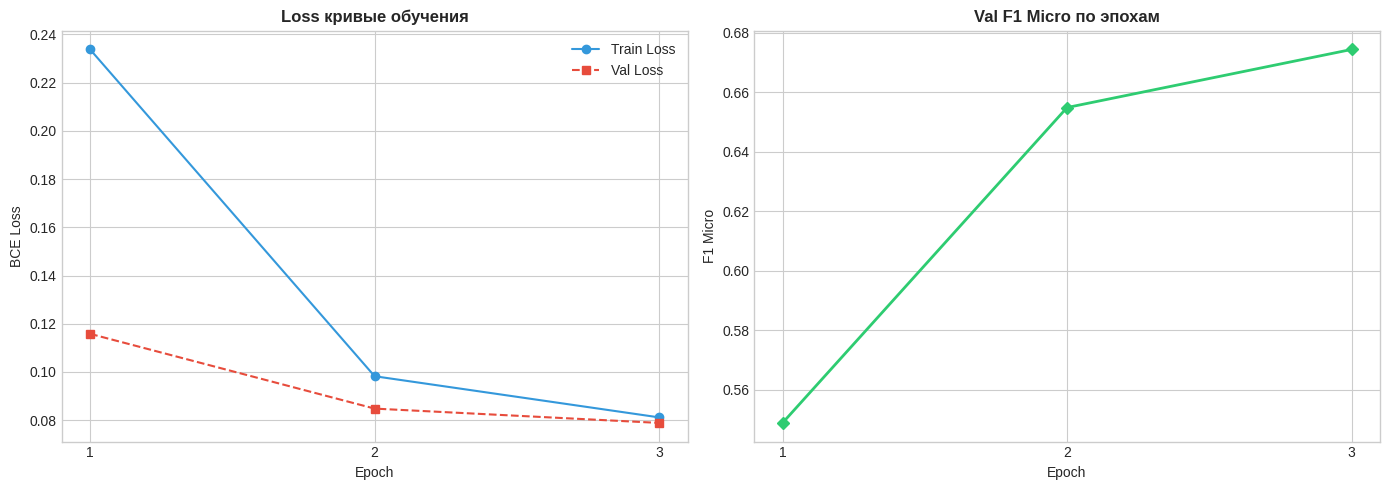

In [22]:
# ── 8.5 Кривые обучения ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#3498db')
ax1.plot(epochs_range, history['val_loss'],   's--', label='Val Loss',  color='#e74c3c')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss кривые обучения', fontweight='bold')
ax1.legend(); ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax2.plot(epochs_range, history['val_f1_micro'], 'D-', color='#2ecc71', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 Micro')
ax2.set_title('Val F1 Micro по эпохам', fontweight='bold')
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig("bert_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── 8.6 Оценка лучшей модели на тестовой выборке ─────────────────────────────
model.load_state_dict(torch.load("best_distilbert_tagger.pt", map_location=DEVICE))
model.eval()

all_logits, all_labels_te = [], []
with torch.no_grad():
    for batch in tqdm(test_dl, desc="Предсказание на тесте"):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = model(ids, mask)
        all_logits.append(torch.sigmoid(logits).cpu().numpy())
        all_labels_te.append(batch['labels'].numpy())

Y_prob_bert = np.vstack(all_logits)
Y_pred_bert = (Y_prob_bert >= THRESHOLD).astype(int)
Y_test_bert = np.vstack(all_labels_te)

metrics_bert = evaluate(Y_test_bert, Y_pred_bert, Y_prob_bert, "DistilBERT Fine-tuned")

Предсказание на тесте:   0%|          | 0/63 [00:00<?, ?it/s]


─────────────────────────────────────────────
  📊 DistilBERT Fine-tuned
─────────────────────────────────────────────
  Hamming Loss           0.0179  ↓
  F1 Micro               0.6766  ↑
  F1 Macro               0.1046  ↑
  Precision Micro        0.9443  ↑
  Recall Micro           0.5271  ↑
  Precision@3            0.4244  ↑
  Precision@5            0.2779  ↑
─────────────────────────────────────────────


## 📊 Шаг 9. Сравнение моделей

In [24]:
# Таблица сравнения
metric_names = list(metrics_base.keys())
comp_df = pd.DataFrame({
    'Метрика':        metric_names,
    'TF-IDF + LogReg': [metrics_base[m] for m in metric_names],
    'DistilBERT':      [metrics_bert[m] for m in metric_names],
})

# Добавляем дельту
comp_df['Δ (BERT - Base)'] = comp_df['DistilBERT'] - comp_df['TF-IDF + LogReg']

# Для Hamming Loss улучшение — это снижение
comp_df.loc[comp_df['Метрика'] == 'Hamming Loss', 'Δ (BERT - Base)'] *= -1

print(comp_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        Метрика  TF-IDF + LogReg  DistilBERT  Δ (BERT - Base)
   Hamming Loss           0.0184      0.0179           0.0006
       F1 Micro           0.6572      0.6766           0.0193
       F1 Macro           0.2251      0.1046          -0.1205
Precision Micro           0.9650      0.9443          -0.0207
   Recall Micro           0.4983      0.5271           0.0288
    Precision@3           0.4962      0.4244          -0.0717
    Precision@5           0.3211      0.2779          -0.0432


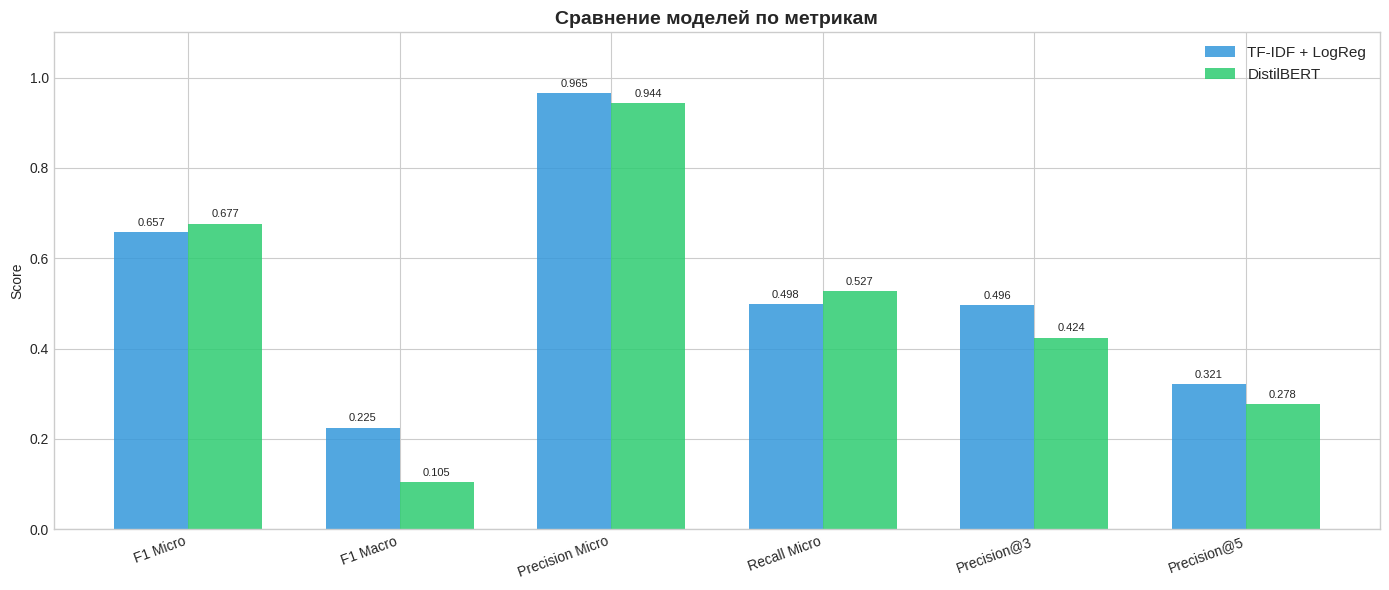

In [25]:
# Визуализация сравнения (без Hamming Loss для нагладности)
plot_metrics = [m for m in metric_names if m != 'Hamming Loss']
x = np.arange(len(plot_metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - w/2, [metrics_base[m] for m in plot_metrics], w,
               label='TF-IDF + LogReg', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, [metrics_bert[m] for m in plot_metrics], w,
               label='DistilBERT', color='#2ecc71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Сравнение моделей по метрикам', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 🔎 Шаг 10. Ручная проверка и анализ ошибок

In [26]:
def predict_tags_bert(text: str, top_k: int = 5, threshold: float = THRESHOLD) -> list[str]:
    """Предсказывает теги для произвольного текста с помощью DistilBERT."""
    model.eval()
    enc = tokenizer(
        text, max_length=MAX_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        logits = model(
            enc['input_ids'].to(DEVICE),
            enc['attention_mask'].to(DEVICE)
        )
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    # Теги выше порога + топ-K по вероятности
    above_thresh = [(mlb.classes_[i], probs[i]) for i in range(len(probs)) if probs[i] >= threshold]
    if not above_thresh:
        top_k_idx    = np.argsort(probs)[-top_k:][::-1]
        above_thresh = [(mlb.classes_[i], probs[i]) for i in top_k_idx]

    return sorted(above_thresh, key=lambda x: -x[1])


# ── Тест на реальных примерах ──────────────────────────────────────────────────
test_questions = [
    "How do I reverse a linked list in Python recursively?",
    "React hooks useState not updating the component after API call",
    "SQL query to find duplicate rows in a MySQL table",
    "How to implement JWT authentication in a Node.js Express REST API?",
    "NullPointerException when calling method on ArrayList in Java",
]

print("\n🔍 Ручная проверка предсказаний DistilBERT:\n" + "═" * 60)
for q in test_questions:
    preds = predict_tags_bert(q)
    tags_str = ", ".join([f"{tag} ({prob:.2f})" for tag, prob in preds])
    print(f"❓ {q}")
    print(f"   🏷️  {tags_str}\n")


🔍 Ручная проверка предсказаний DistilBERT:
════════════════════════════════════════════════════════════
❓ How do I reverse a linked list in Python recursively?
   🏷️  python (0.88)

❓ React hooks useState not updating the component after API call
   🏷️  javascript (0.83)

❓ SQL query to find duplicate rows in a MySQL table
   🏷️  c# (0.44), python (0.22), java (0.21), string (0.12), .net (0.11)

❓ How to implement JWT authentication in a Node.js Express REST API?
   🏷️  javascript (0.90)

❓ NullPointerException when calling method on ArrayList in Java
   🏷️  java (0.91)



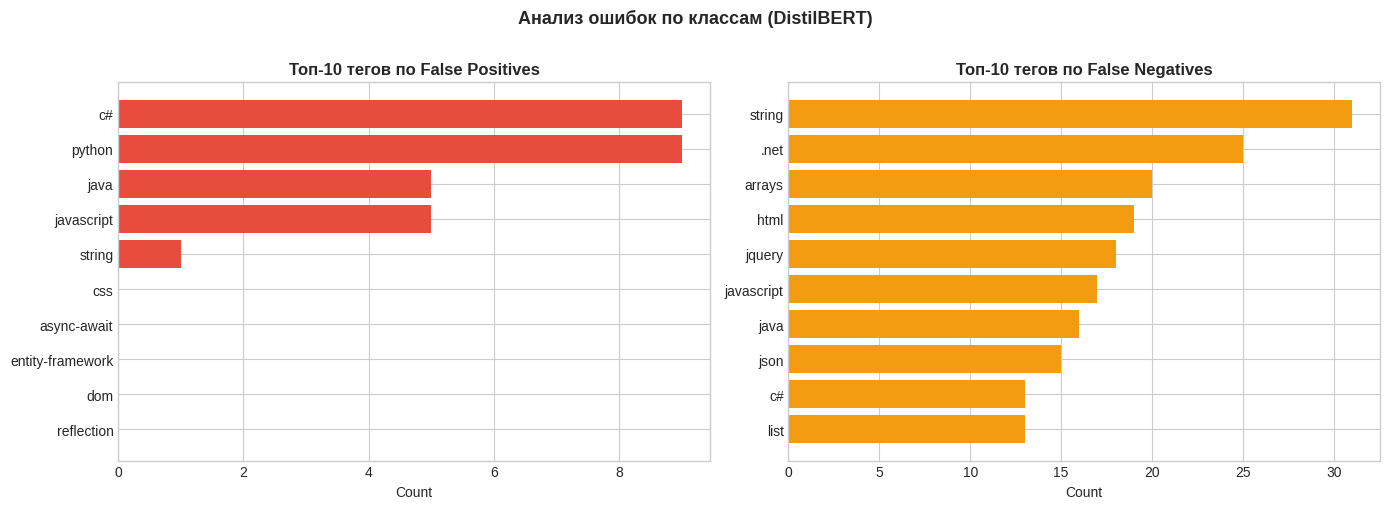

In [27]:
# ── Анализ ошибок: FP и FN ────────────────────────────────────────────────────
# Берём небольшую выборку из теста
N_ANALYSIS = min(500, len(Y_test_bert))
Y_sample_true = Y_test_bert[:N_ANALYSIS]
Y_sample_pred = Y_pred_bert[:N_ANALYSIS]

fp_per_class = ((Y_sample_pred == 1) & (Y_sample_true == 0)).sum(axis=0)  # False Positive
fn_per_class = ((Y_sample_pred == 0) & (Y_sample_true == 1)).sum(axis=0)  # False Negative

top10_fp_idx = np.argsort(fp_per_class)[-10:][::-1]
top10_fn_idx = np.argsort(fn_per_class)[-10:][::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh([mlb.classes_[i] for i in top10_fp_idx[::-1]],
          [fp_per_class[i] for i in top10_fp_idx[::-1]], color='#e74c3c')
ax1.set_title('Топ-10 тегов по False Positives', fontweight='bold')
ax1.set_xlabel('Count')

ax2.barh([mlb.classes_[i] for i in top10_fn_idx[::-1]],
          [fn_per_class[i] for i in top10_fn_idx[::-1]], color='#f39c12')
ax2.set_title('Топ-10 тегов по False Negatives', fontweight='bold')
ax2.set_xlabel('Count')

plt.suptitle('Анализ ошибок по классам (DistilBERT)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Шаг 11. Оптимизация порога предсказания

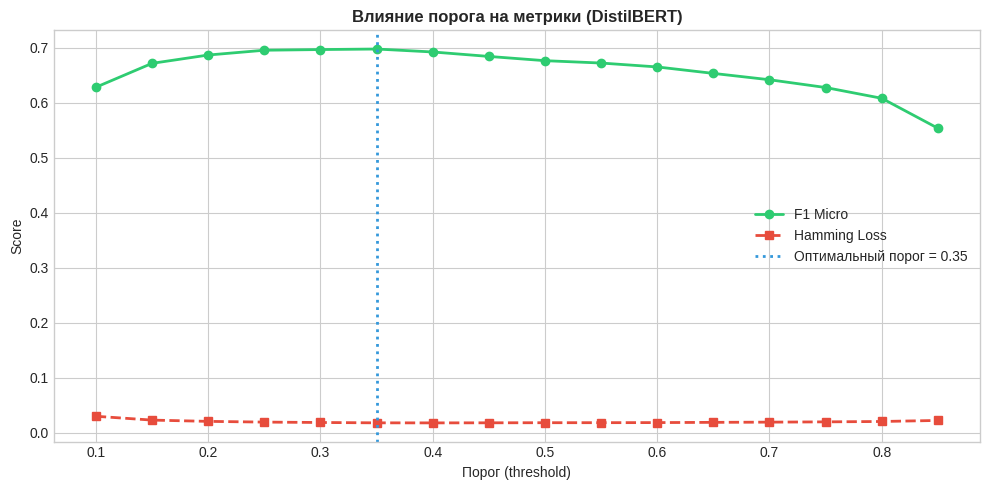


🎯 Оптимальный порог: 0.35  →  F1 Micro: 0.6978


In [28]:
thresholds = np.arange(0.1, 0.9, 0.05)
f1_micro_vals, hamming_vals = [], []

for thresh in thresholds:
    Y_pred_t = (Y_prob_bert >= thresh).astype(int)
    f1_micro_vals.append(f1_score(Y_test_bert, Y_pred_t, average='micro', zero_division=0))
    hamming_vals.append(hamming_loss(Y_test_bert, Y_pred_t))

best_thresh_idx = np.argmax(f1_micro_vals)
best_thresh     = thresholds[best_thresh_idx]
best_f1         = f1_micro_vals[best_thresh_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_micro_vals, 'o-', color='#2ecc71', label='F1 Micro', lw=2)
ax.plot(thresholds, hamming_vals,  's--', color='#e74c3c', label='Hamming Loss', lw=2)
ax.axvline(x=best_thresh, color='#3498db', linestyle=':', lw=2,
           label=f'Оптимальный порог = {best_thresh:.2f}')
ax.set_xlabel('Порог (threshold)')
ax.set_ylabel('Score')
ax.set_title('Влияние порога на метрики (DistilBERT)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🎯 Оптимальный порог: {best_thresh:.2f}  →  F1 Micro: {best_f1:.4f}")

In [29]:
# Финальная оценка с оптимальным порогом
Y_pred_optimal = (Y_prob_bert >= best_thresh).astype(int)
metrics_bert_opt = evaluate(
    Y_test_bert, Y_pred_optimal, Y_prob_bert,
    f"DistilBERT (threshold={best_thresh:.2f})"
)


─────────────────────────────────────────────
  📊 DistilBERT (threshold=0.35)
─────────────────────────────────────────────
  Hamming Loss           0.0176  ↓
  F1 Micro               0.6978  ↑
  F1 Macro               0.1366  ↑
  Precision Micro        0.8882  ↑
  Recall Micro           0.5746  ↑
  Precision@3            0.4244  ↑
  Precision@5            0.2779  ↑
─────────────────────────────────────────────


## 📋 Шаг 12. Итоговый отчёт

In [30]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          ИТОГОВЫЙ ОТЧЁТ: Auto-Tagging StackOverflow          ║
╠══════════════════════════════════════════════════════════════╣
║  Датасет:   10 000+ вопросов StackOverflow                   ║
║  Задача:    Multi-label классификация (топ-50 тегов)         ║
╠══════════════════════════════════════════════════════════════╣
║  БАЗОВАЯ МОДЕЛЬ: TF-IDF (50k n-грамм) + LogReg OneVsRest    ║
║  ПРОДВИНУТАЯ:    DistilBERT fine-tuning (3 эпохи)           ║
╠══════════════════════════════════════════════════════════════╣""")

metrics_list = [
    ("Hamming Loss   ↓", metrics_base['Hamming Loss'],    metrics_bert_opt['Hamming Loss'],    True),
    ("F1 Micro       ↑", metrics_base['F1 Micro'],        metrics_bert_opt['F1 Micro'],        False),
    ("F1 Macro       ↑", metrics_base['F1 Macro'],        metrics_bert_opt['F1 Macro'],        False),
    ("Precision Micro↑", metrics_base['Precision Micro'], metrics_bert_opt['Precision Micro'], False),
    ("Recall Micro   ↑", metrics_base['Recall Micro'],    metrics_bert_opt['Recall Micro'],    False),
    ("Precision@3    ↑", metrics_base['Precision@3'],     metrics_bert_opt['Precision@3'],     False),
]

for name, base_val, bert_val, lower_is_better in metrics_list:
    better = bert_val < base_val if lower_is_better else bert_val > base_val
    sign   = "✅" if better else "⚠️"
    delta  = bert_val - base_val
    print(f"║  {name:<20} Base={base_val:.4f}  BERT={bert_val:.4f}  Δ={delta:+.4f} {sign}  ║")



╔══════════════════════════════════════════════════════════════╗
║          ИТОГОВЫЙ ОТЧЁТ: Auto-Tagging StackOverflow          ║
╠══════════════════════════════════════════════════════════════╣
║  Датасет:   10 000+ вопросов StackOverflow                   ║
║  Задача:    Multi-label классификация (топ-50 тегов)         ║
╠══════════════════════════════════════════════════════════════╣
║  БАЗОВАЯ МОДЕЛЬ: TF-IDF (50k n-грамм) + LogReg OneVsRest    ║
║  ПРОДВИНУТАЯ:    DistilBERT fine-tuning (3 эпохи)           ║
╠══════════════════════════════════════════════════════════════╣
║  Hamming Loss   ↓     Base=0.0184  BERT=0.0176  Δ=-0.0008 ✅  ║
║  F1 Micro       ↑     Base=0.6572  BERT=0.6978  Δ=+0.0405 ✅  ║
║  F1 Macro       ↑     Base=0.2251  BERT=0.1366  Δ=-0.0885 ⚠️  ║
║  Precision Micro↑     Base=0.9650  BERT=0.8882  Δ=-0.0768 ⚠️  ║
║  Recall Micro   ↑     Base=0.4983  BERT=0.5746  Δ=+0.0763 ✅  ║
║  Precision@3    ↑     Base=0.4962  BERT=0.4244  Δ=-0.0717 ⚠️  ║
╠══════════════════════

## 💡 Шаг 13. Возможные улучшения

| Направление | Метод | Ожидаемый прирост |
|---|---|---|
| Больше данных | StackExchange Data Dump (все вопросы) | +5-10% F1 |
| Лучшая архитектура | RoBERTa-base, DeBERTa | +2-5% F1 |
| Label correlation | Classifier Chains, LSAN | +1-3% F1 Macro |
| Augmentation | Back-translation, EDA | +1-2% |
| Class imbalance | Focal Loss, over/undersampling | +2-4% F1 Macro |
| Per-class thresholds | Оптимизация порога для каждого тега | +1-3% |
| Code understanding | CodeBERT для блоков кода | Специфично для SO |

In [31]:
# ── Интерактивный демо-инференс ───────────────────────────────────────────────
def demo_predict(question: str) -> None:
    """Красивый вывод предсказания для произвольного вопроса."""
    preds = predict_tags_bert(question, threshold=best_thresh)
    print(f"\n{'─'*60}")
    print(f"❓ Вопрос:\n   {question}")
    print(f"\n🏷️  Предсказанные теги:")
    for tag, prob in preds:
        bar = '█' * int(prob * 20) + '░' * (20 - int(prob * 20))
        print(f"   {tag:<20} [{bar}] {prob:.3f}")
    print(f"{'─'*60}")

demo_predict("How to handle async/await errors in Python FastAPI with SQLAlchemy?")
demo_predict("What is the time complexity of sorting algorithms in Java Collections?")


────────────────────────────────────────────────────────────
❓ Вопрос:
   How to handle async/await errors in Python FastAPI with SQLAlchemy?

🏷️  Предсказанные теги:
   python               [█████████████████░░░] 0.875
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
❓ Вопрос:
   What is the time complexity of sorting algorithms in Java Collections?

🏷️  Предсказанные теги:
   java                 [████████████████░░░░] 0.833
────────────────────────────────────────────────────────────
